# Демо 5. Анимация вставания и приседания человека

*Источник:* П.А. Кручинин. Об освоении пакета MATLAB с использованием практических задач. Здесь задача переведена на Python.

## Постановка задачи

Координаты нескольких точек на теле человека записаны в таблицу: каждая строка соответствует моменту времени, интервал между строками постоянен. Нужно показать движение в профиль (в сагиттальной плоскости) в виде анимации. Используются точки: плечо, корпус, тазобедренный сустав, колено, щиколотка, пальцы стопы.

Анимация помогает, например, оценить правдоподобие математической модели движения.

**Что отрабатываем:** загрузку таблицы из файла, индексацию столбцов массивом номеров, анимацию (`matplotlib.animation`) и обновление графика без перерисовки (`set_data`).

> **Данные синтетические.** Файл `data/adc_synthetic.txt` сгенерирован скриптом `data/make_synthetic.py` по упрощённой кинематической модели и служит заглушкой. Формат повторяет файл `adc.txt` MATLAB-версии курса. Если пример останется в курсе, его нужно заменить экспериментальными данными или результатами моделирования.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# СИНТЕТИЧЕСКИЕ данные (заглушка): строка -- момент времени, координаты в мм
adc = np.loadtxt('data/adc_synthetic.txt', encoding='utf-8')
print('размер таблицы:', adc.shape)

# номера столбцов x-координат (как в MATLAB, с единицы):
# плечо, корпус, таз, колено, щиколотка, стопа; y -- в следующем столбце
s_matlab = np.array([23, 20, 17, 14, 11, 8])
s = s_matlab - 1          # в Python столбцы нумеруются с нуля

размер таблицы: (900, 26)


## Последовательность поз

Выборка каждой тридцатой строки. В MATLAB для этого индексировали `adc(k, s)`, в Python — `adc[k, s]`: столбцы выбираются сразу массивом номеров.

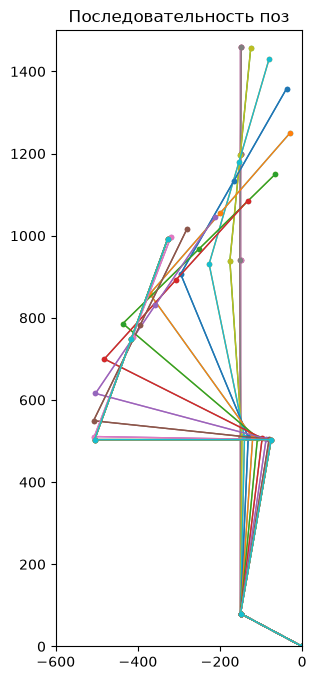

In [2]:
fig, ax = plt.subplots(figsize=(4, 8))
for k in range(0, len(adc), 30):
    ax.plot(adc[k, s], adc[k, s + 1], '-o', ms=3, lw=1)
ax.set_xlim(-600, 0)
ax.set_ylim(0, 1500)
ax.set_aspect('equal')
ax.set_title('Последовательность поз')
plt.show()

## Анимация

Вместо MATLAB-функций `moviein`/`getframe`/`movie` используется класс `FuncAnimation`. Функция `update` получает номер кадра и меняет данные уже нарисованной линии методом `set_data`. Это аналог `set(hp, 'XData', x, 'YData', y)`.

В ноутбуке анимация показывается через `HTML(anim.to_jshtml())`. Сохранить её в файл можно командой `anim.save('stand_up.gif', writer='pillow')`. В обычном скрипте можно обойтись циклом с `line.set_data(...)` и `plt.pause(0.1)`.

In [3]:
frames = range(0, len(adc), 20)          # каждый 20-й отсчёт

fig, ax = plt.subplots(figsize=(3, 6))
line, = ax.plot([], [], '-o', lw=3, ms=5)
ax.set_xlim(-600, 0)
ax.set_ylim(0, 1500)
ax.set_aspect('equal')
ax.set_axis_off()                         # как 'Visible','off' в MATLAB


def update(k):
    line.set_data(adc[k, s], adc[k, s + 1])
    return line,


anim = animation.FuncAnimation(fig, update, frames=frames, interval=100, blit=True)
plt.close(fig)                            # не показывать пустую статичную фигуру
HTML(anim.to_jshtml())

**Что попробовать:**
- добавьте на рисунок траекторию тазобедренного сустава (след за несколько последних кадров);
- вычислите по данным углы в коленном и тазобедренном суставах и постройте их графики от времени;
- замените табличные данные расчётом координат по математической модели (кинематическая цепь с заданными углами).